# 1 Introducción

**Objetivo:** aplicar PCA para reducir la dimensión de los datos; imágenes principalmente

**PCA con scikit-learn:**

* El método directo (y eficiente) para calcular PCA se basa en hallar la SVD "completa" de la matriz de datos
* La implementación de PCA en scikit-learn emplea un método aleatorizado, más eficiente que el directo

**Aplicación a imágenes:**

* Usaremos datasets muy populares: MNIST, Fashion-MNIST y CIFAR-10
* La dimensión de los datos en el caso de imágenes suele ser muy grande, lo que dificulta el aprendizaje de clasificadores
* Una aproximación convencional para facilitar el aprendizaje consiste en reducir previamente la dimensión de los datos
* Estudiaremos el error de reconstrucción en función de la dimensión reducida $K$
* Interpretaremos las componentes principales como imágenes base (*eigenimages*)
* Reconstruiremos imágenes y las compararemos con sus originales
* Estudiaremos la precisión de regresión logística en función de $K$
* Aunque trabajemos con imágenes, se puede proceder de forma parecida con otro tipo de datos (de alta dimensión)

# 2 PCA con scikit-learn

**Método directo para aplicar PCA:** a partir de la SVD "completa" de la matriz de datos

**Ejemplo:** $N = 4$ datos de $D = 2$ dimensiones que queremos reducir a $K = 1$ dimensión

Ejemplo como hacerlo con las formulas usando el SVG original

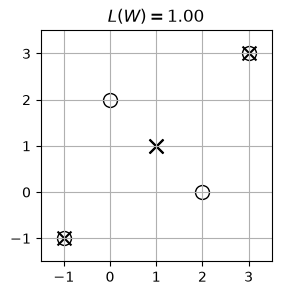

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de datos de entrada (N=4 muestras, D=2 dimensiones)
X = np.array([
    [-1, -1],
    [ 0,  2],
    [ 2,  0],
    [ 3,  3]
])
N = len(X)

# Dimensiones a las que queremos reducir los datos
K = 1

# 1. Centrado de datos (restar la media) y cálculo de la SVD (Descomposición en Valores Singulares)
# Vt contiene las componentes principales en sus filas
_, _, Vt = np.linalg.svd(X - X.mean(0))

# 2. Selección de las primeras K componentes vectoriales principales (Matriz de proyección W)
W = Vt[:K, :].T

# 3. Proyección de los datos centrados al espacio reducido de dimensión K (matriz Z)
Z = X @ W

# 4. Reconstrucción de los datos aproximados en la dimensión original D (matriz hX)
hX = Z @ W.T

# 5. Cálculo del error medio cuadrático de reconstrucción (pérdida L)
L = np.square(X - hX).sum(axis=1).mean()

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(3, 3)) 
ax.set_aspect("equal")  # Mantener la misma escala en ambos ejes

# Límites de los ejes y rejilla
plt.axis([-1.5, 3.5, -1.5, 3.5]) 
plt.grid(True)

# Título del gráfico mostrando el valor de la pérdida
ax.set_title(f'$L(W)={L:.2f}$')

# Dibujar puntos originales (círculos blancos con borde negro)
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=100)

# Dibujar puntos proyectados/reconstruidos (cruces negras)
plt.scatter(*hX.T, facecolor='black', s=100, marker='x');

**PCA con scikit-learn:** emplea un método aleatorizado para matrices grandes, más eficiente que el directo

* **API:** https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
* **Parámetros:** `n_components`, `svd_solver`, `random_state`, etc.
* **Atributos:** `components_`, `singular_values_`, `mean_`, `n_components_`, etc.
* **Métodos:** `fit(X)`, `transform(X)`, `fit_transform(X)`, `inverse_transform(X)`, etc.

**Ejemplo (cont.):** con scikit-learn, `n_components` = $K$

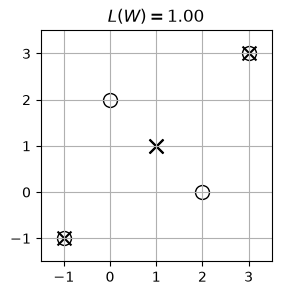

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Matriz de datos de entrada (N=4 datos, D=2 dimensiones)
X = np.array([
    [-1, -1],
    [ 0,  2],
    [ 2,  0],
    [ 3,  3]
])
N = len(X)

# Número de componentes principales deseado
K = 1

# Ajustar el modelo PCA restando la media a los datos (centrado de datos)
pca = PCA(n_components=K).fit(X - X.mean(0))

# Proyectar los datos al espacio de dimensión reducida (matriz Z)
Z = pca.transform(X)

# Reconstruir las dimensiones originales desde el espacio reducido (matriz hX)
hX = pca.inverse_transform(Z)

# Calcular la pérdida / error medio de reconstrucción
L = np.square(X - hX).sum(axis=1).mean()

# Configuración de la figura para la visualización
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.grid(True)
ax.set_title(f'$L(W)={L:.2f}$')

# Dibujar los datos originales (puntos blancos con borde negro)
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=100)

# Dibujar los datos reconstruidos (cruces negras)
plt.scatter(*hX.T, facecolor='black', s=100, marker='x');

# 3 MNIST

**Modified NIST (MNIST):** dataset de 70 000 imágenes $28 \times 28$ en gris de dígitos manuscritos

**Muy popular:** desde su introducción en los 90, MNIST ha sido muy usado para comparar técnicas de ML

**Partición estándar:** 60 000 primeras muestras para training y 10 000 restantes para test

In [3]:
import numpy as np; 
import datasets 
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy")
ds

/home/abigbean/D/UPV/2do/UPV/APA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 512419.09 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [4]:
train0 = ds['train'][0] 
train0['image'].shape, train0['image'].dtype, train0['label']

((28, 28), dtype('uint8'), np.int64(5))

**Agotado**:  pues ya se han alcanzado tasas de error muy reducidas, por debajo del *0.1%*

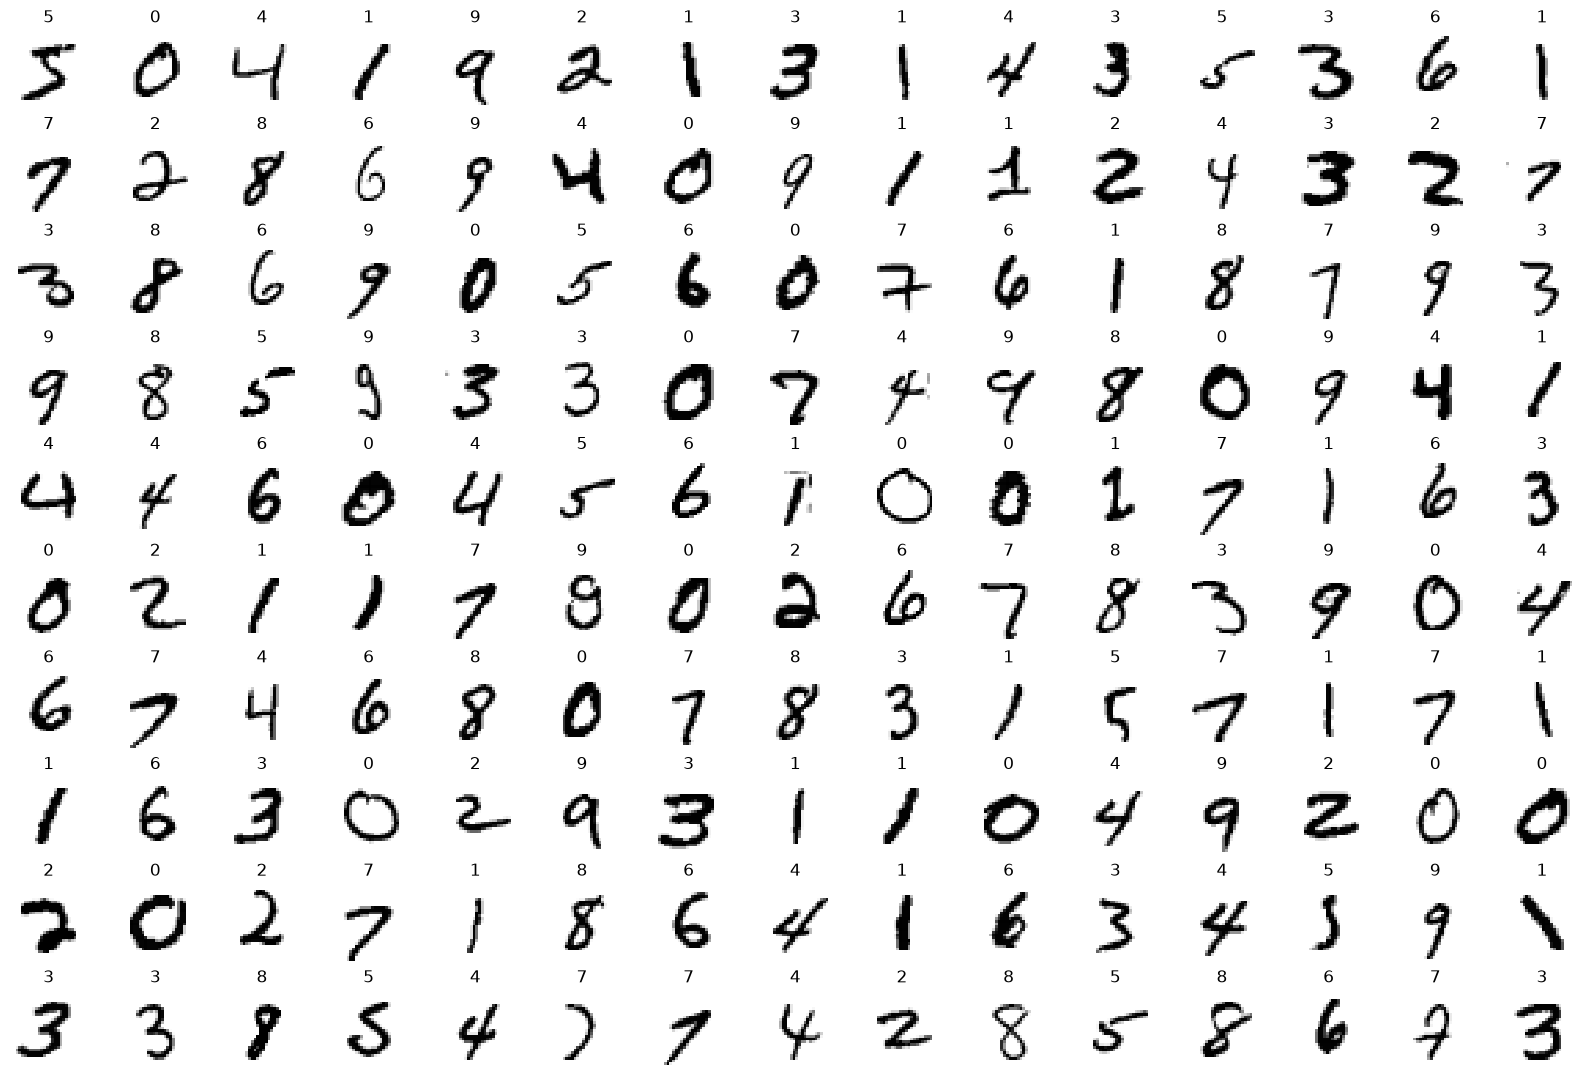

In [5]:
import matplotlib.pyplot as plt

# Configurar las dimensiones de la cuadrícula (10 filas x 15 columnas = 150 muestras)
nrows = 10
ncols = 15
N = nrows * ncols

# Crear la figura y el grid de ejes adaptando el tamaño proporcionalmente a la cuadrícula
_, axs = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(16, 16 * nrows / ncols), 
    constrained_layout=True
)

# Iterar sobre los subplots planos, las imágenes y sus etiquetas correspondientes
for ax, x, y in zip(axs.flat, ds['train'][:N]['image'], ds['train'][:N]['label']):
    ax.set_axis_off()  # Ocultar los ejes y marcadores
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")  # Renderizar imagen en escala de grises invertida
    ax.set_title(y)  # Colocar la etiqueta numérica como título

# 4 PCA aplicado a MNIST

**Error de reconstrucción:**  estudio en función de *K*

In [ ]:
import numpy as np; 
import datasets 
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy") 

# .reshape(-1, 28*28): Aplana la imagen (pasa de matriz 28x28 a un vector de 784 píxeles).
# / 255.             : Normaliza los píxeles de [0, 255] a [0.0, 1.0] para acelerar el entrenamiento.

X_train = ds['train'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255. 
y_train = ds['train'][:]['label'].astype(np.uint8) 
X_test = ds['test'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255. 
y_test = ds['test'][:]['label'].astype(np.uint8)

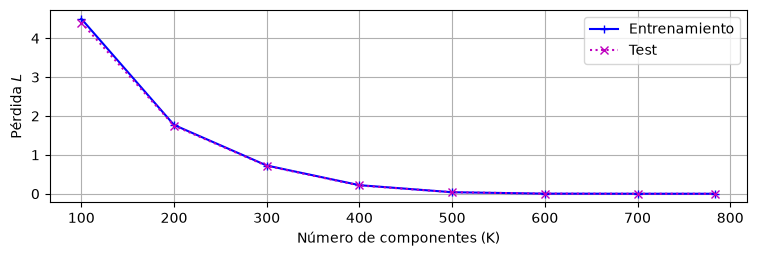

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Determinar el número máximo de componentes posibles (mínimo entre el número de muestras y características)
max_K = np.min(X_train.shape)

# Entrenar el modelo PCA con el número máximo de componentes principales
# Calcula los 784 autovectores (componentes principales) y sus respectivos autovalores a partir del conjunto de entrenamiento.
pca = PCA(n_components=max_K).fit(X_train)

# Transformar/proyectar los conjuntos de datos al espacio de componentes principales
# Convierte las imágenes del espacio de píxeles original (784 dimensiones) al espacio de componentes principales Z. 

Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)


# Definir los distintos valores de K (dimensiones reducidas) a evaluar
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])

# Crear vectores vacíos para almacenar las pérdidas (errores de reconstrucción)
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)

# Calcular el error de reconstrucción para cada número de componentes K
for i, K in enumerate(Ks):
    # --- Evaluación en conjunto de entrenamiento ---
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0  # Anular todas las componentes superiores a K
    hX_train = pca.inverse_transform(Z_train_K)  # Reconstruir a la dimensión original
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()  # Calcular error cuadrático medio

    # --- Evaluación en conjunto de test ---
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0  # Anular todas las componentes superiores a K
    hX_test = pca.inverse_transform(Z_test_K)  # Reconstruir a la dimensión original
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()  # Calcular error cuadrático medio

# Visualización del error en función de K
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, '+-b', label='Entrenamiento')
plt.plot(Ks, L_test, 'x:m', label='Test')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Pérdida $L$')
plt.legend();

**Eigendigits y reconstrucción:**  con *K = 400*

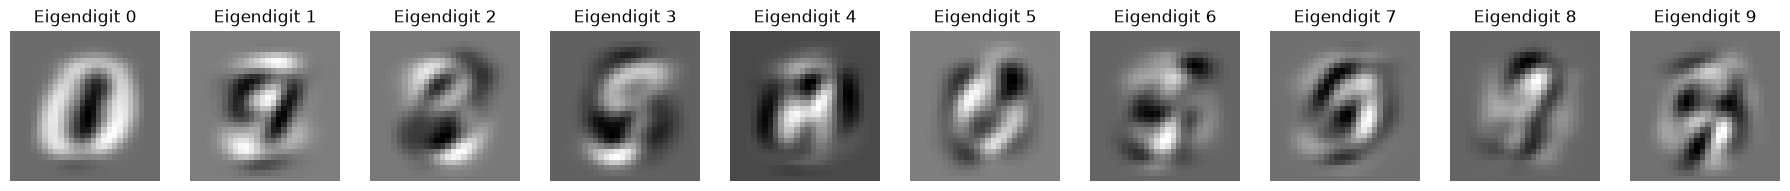

In [ ]:
# Definir el número de componentes principales a extraer
K = 400

# Entrenar el modelo PCA con el conjunto de entrenamiento
pca = PCA(n_components=K).fit(X_train)

# Definir la estructura de la cuadrícula de visualización (1 fila x 10 columnas)
nrows, ncols = 1, 10

# Crear la figura con subplots adaptando el tamaño proporcionalmente
fig, axs = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(18, 18 * nrows / ncols), 
    constrained_layout=True
)

# Iterar sobre los primeros K autovectores 
for i in range(min(K, nrows * ncols)):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"Eigendigit {i}") 
    # Redimensionar la i-ésima componente principal de vector 1D a matriz de 28x28 px y graficar
    ax.imshow(
        pca.components_[i, :].reshape((28, 28)), 
        cmap=plt.cm.gray, 
        interpolation="none"
    )

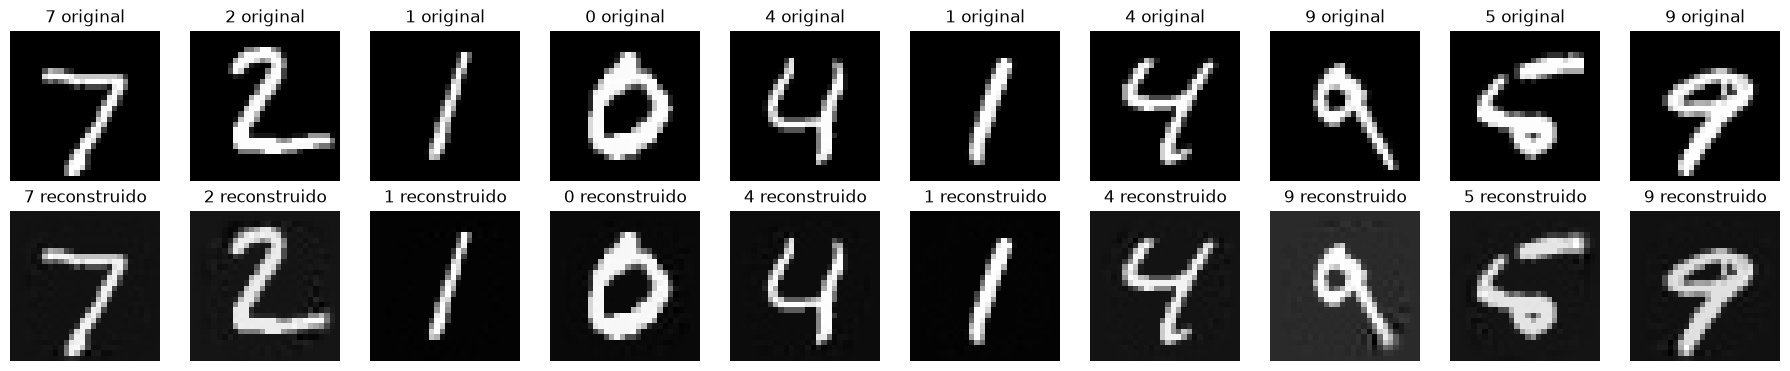

In [ ]:
import matplotlib.pyplot as plt

# Número de imágenes a mostrar y comparar
ncols = 10

# Proyectar las primeras 'ncols' imágenes de test al espacio reducido
Z_test = pca.transform(X_test[:ncols])

# Reconstruir las imágenes desde las componentes principales a la dimensión original
hX_test = pca.inverse_transform(Z_test)

# Crear una cuadrícula de 2 filas (fila 1: originales, fila 2: reconstruidas) y 10 columnas
fig, axs = plt.subplots(
    nrows=2, 
    ncols=ncols, 
    figsize=(18, 18 * 2 / ncols), 
    constrained_layout=True
)

# Renderizar cada pareja de imágenes (original y reconstruida)
for i in range(ncols):
    # Imagen Original 
    ax = axs.flat[i]
    ax.set_axis_off()  # Ocultar los ejes
    ax.set_title(f"{y_test[i]} original")
    ax.imshow(
        X_test[i, :].reshape((28, 28)), 
        cmap=plt.cm.gray, 
        interpolation="none"
    )

    

**Precisión de regresión logística:**  estudio en función de *K*

Este código mide cómo afecta la reducción de dimensionalidad por PCA al rendimiento de un modelo de Regresión Logística (clasificación), 
evaluando la accuracy lograda en función del número de componentes principales K utilizadas.

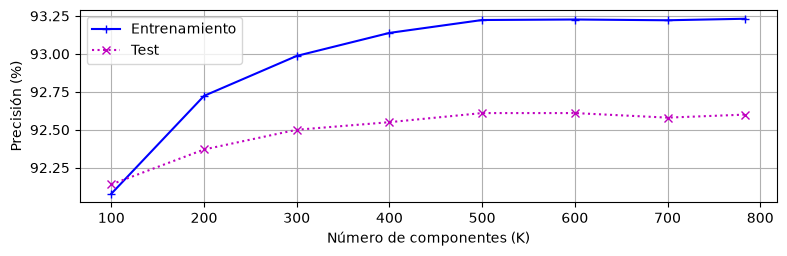

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Determinar el número máximo de componentes principales posibles
max_K = np.min(X_train.shape)

# Entrenar el modelo PCA con la máxima cantidad de componentes
pca = PCA(n_components=max_K).fit(X_train)

# Transformar los conjuntos de datos al espacio de componentes principales
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)

# Definir los distintos valores de K (dimensiones reducidas) a evaluar
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])

# Crear vectores vacíos para almacenar la precisión (accuracy)
acc_train = np.empty_like(Ks, dtype=float)
acc_test = np.empty_like(Ks, dtype=float)

# Evaluar el modelo de clasificación variando el número de componentes K
for i, K in enumerate(Ks):
    # Entrenar Regresión Logística usando solo las primeras K componentes
    clf = LogisticRegression(C=0.1, max_iter=200).fit(Z_train[:, :K], y_train)
    
    # Calcular y almacenar la precisión (%) en entrenamiento y test
    acc_train[i] = clf.score(Z_train[:, :K], y_train)
    acc_test[i] = clf.score(Z_test[:, :K], y_test)

# Gráfico de precisión en función del número de componentes K
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, 100. * acc_train, '+-b', label='Entrenamiento')
plt.plot(Ks, 100. * acc_test, 'x:m', label='Test')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Precisión (%)')
plt.legend();

In [14]:
for i, K in enumerate(Ks): 
    print(f'K:{K} -> {acc_test[i]:.1%}', end='\n')

K:100 -> 92.1%
K:200 -> 92.4%
K:300 -> 92.5%
K:400 -> 92.5%
K:500 -> 92.6%
K:600 -> 92.6%
K:700 -> 92.6%
K:784 -> 92.6%


# 5 Fashion-MNIST 
## Fashion MNIST:  
**MNIST con prendas de ropa**; introducido en 2017 como sustituto del ya agotado MNIST

In [15]:
import numpy as np 
import datasets 
ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy") 
ds

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 629416.25 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

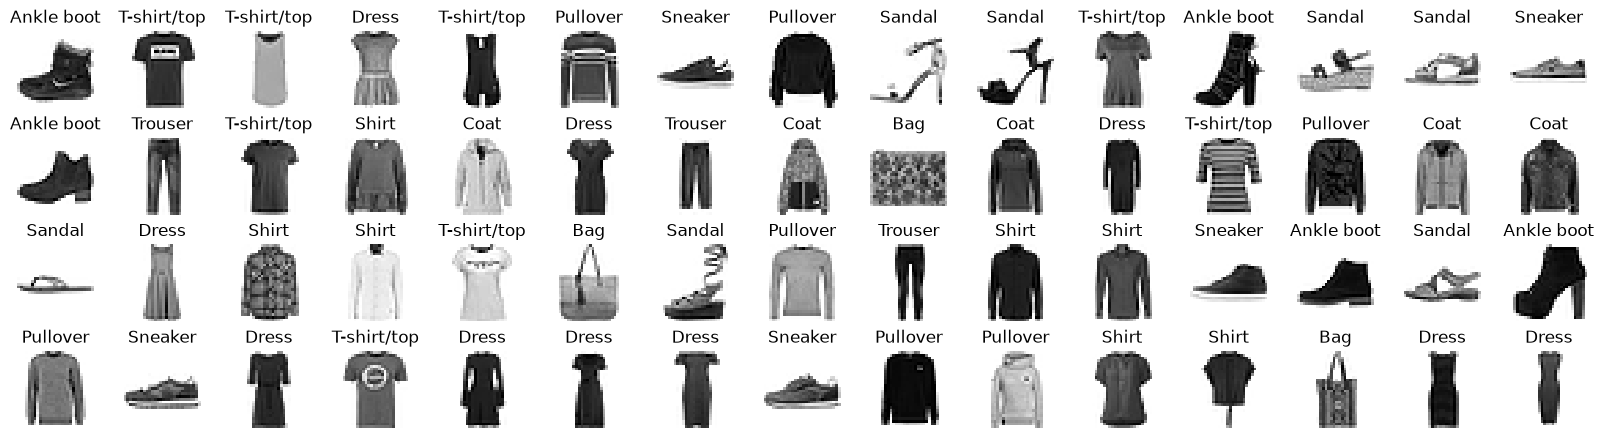

In [16]:
import matplotlib.pyplot as plt

# Definir la estructura de la cuadrícula de visualización (4 filas x 15 columnas = 60 muestras)
nrows = 4
ncols = 15
N = nrows * ncols

# Mapeo de las etiquetas numéricas (0 a 9) a los nombres de las clases de Fashion-MNIST
labels = (
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
)

# Crear la figura y la cuadrícula de subplots ajustando el tamaño proporcionalmente
_, axs = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(16, 16 * nrows / ncols), 
    constrained_layout=True
)

# Iterar en paralelo sobre cada sub-eje, imagen y su correspondiente etiqueta numérica
for ax, x, y in zip(axs.flat, ds['train'][:N]['image'], ds['train'][:N]['label']):
    ax.set_axis_off()  # Ocultar los ejes y marcas numéricas de la gráfica
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")  # Dibujar la imagen en escala de grises invertida
    ax.set_title(labels[y])  # Asignar como título el nombre textual de la prenda usando la etiqueta como índice

# 6 CIFAR-10
## CIFAR-10: 
dataset de: 60000 imágenes 32 ×32 a color de 10 clases; 6000 por clase

In [17]:
import numpy as np 
import datasets 
ds = datasets.load_dataset("uoft-cs/cifar10").with_format("numpy")
ds

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 357610.31 examples/s]


DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [18]:
train0 = ds['train'][0] 
train0['img'].shape, train0['img'].dtype, train0['label']

((32, 32, 3), dtype('uint8'), np.int64(0))

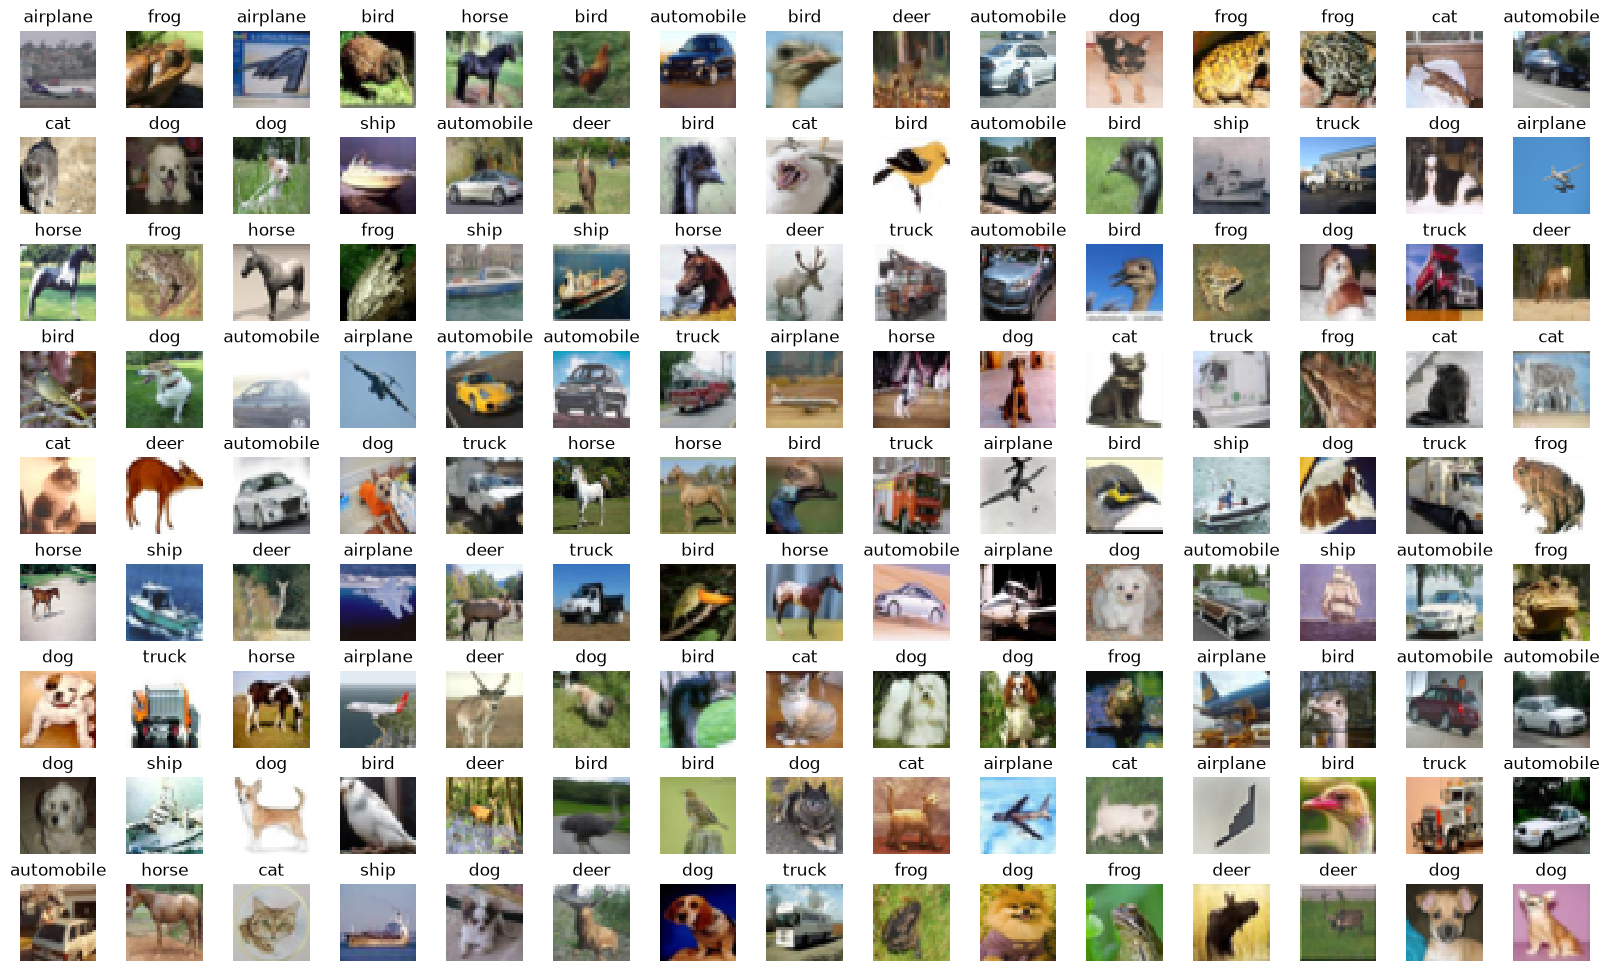

In [19]:
import matplotlib.pyplot as plt

# Definir la estructura de la cuadrícula de visualización (9 filas x 15 columnas = 135 muestras)
nrows = 9
ncols = 15
N = nrows * ncols

# Mapeo de las etiquetas numéricas (0 a 9) a los nombres de las clases (CIFAR-10)
labels = (
    "airplane", "automobile", "bird", "cat", "deer", 
    "dog", "frog", "horse", "ship", "truck"
)

# Crear la figura y la cuadrícula de subplots adaptando el tamaño de forma proporcional
_, axs = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(16, 16 * nrows / ncols), 
    constrained_layout=True
)

# Iterar en paralelo sobre cada sub-eje, imagen y su correspondiente etiqueta numérica
for ax, x, y in zip(axs.flat, ds['train'][:N]['img'], ds['train'][:N]['label']):
    ax.set_axis_off()  # Ocultar los ejes y las marcas numéricas del subplot
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")  # Renderizar la imagen sin interpolación
    ax.set_title(labels[y])  # Colocar como título el nombre de la categoría usando la etiqueta como índice

# 7 Ejercicio

**Ejercicio:** aplica PCA a Fashion-MNIST y CIFAR-10 siguiendo el ejemplo dado para MNIST

**Aplicación a Fashion-MNIST:** en comparación con el ejemplo dado para MNIST

* Comprueba que, para obtener un error reconstrucción prácticamente nulo, $K \ge 600$ (aprox.)
* Representa los diez primeros eigenarticles con $K = 600$
* Compara las diez primeras imágenes de test con sus reconstrucciones usando $K = 600$
* Comprueba que regresión logística supera ligeramente el 84% de precisión en test con $K \ge 200$

**Aplicación a CIFAR-10:** en comparación con el ejemplo dado para MNIST

* Comprueba que, para obtener un error reconstrucción prácticamente nulo, $K \ge 1000$ (aprox.)
* No trates de representar gráficamente los diez primeros eigenobjects (requiere un PCA por cada canal de color)
* Compara las diez primeras imágenes de test con sus reconstrucciones usando $K = 1000$
* Comprueba que regresión logística obtiene, aproximadamente, un 41% de precisión en test con $K \ge 200$

# SOLUCIONES

## EJERCICIO 1

### Evaluar y graficar el error de reconstrucción

d:\Family\Aleksey\UPV\2curso\APA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


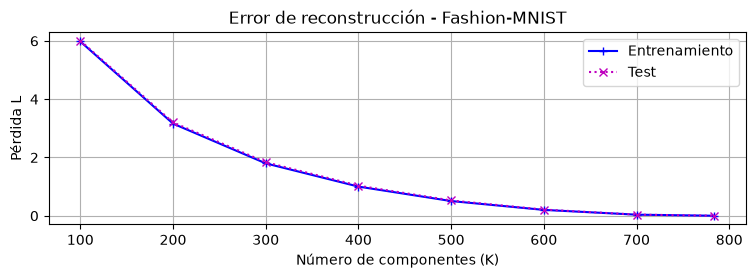

In [2]:
import numpy as np
import datasets
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fashion_mnist = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy") 

X_train = fashion_mnist['train'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255. 
y_train = fashion_mnist['train'][:]['label'].astype(np.uint8) 
X_test = fashion_mnist['test'][:]['image'].astype(np.float32).reshape(-1, 28*28) / 255. 
y_test = fashion_mnist['test'][:]['label'].astype(np.uint8)

# Entrenar PCA con el máximo de componentes
max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)

# Transformar los datasets al espacio de componentes principales
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)

# Definir valores de K y calcular la pérdida de reconstrucción
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)

for i, K in enumerate(Ks):
    # Training
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0
    hX_train = pca.inverse_transform(Z_train_K)
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()

    # Testing
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0  
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()

plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, '+-b', label='Entrenamiento')
plt.plot(Ks, L_test, 'x:m', label='Test')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Pérdida L')
plt.title('Error de reconstrucción - Fashion-MNIST')
plt.legend()
plt.show()

Como se puede ver que es verdad, con K=600 el error es casi nulo

### Representación de los primeros 10 eigenarticles con K=600

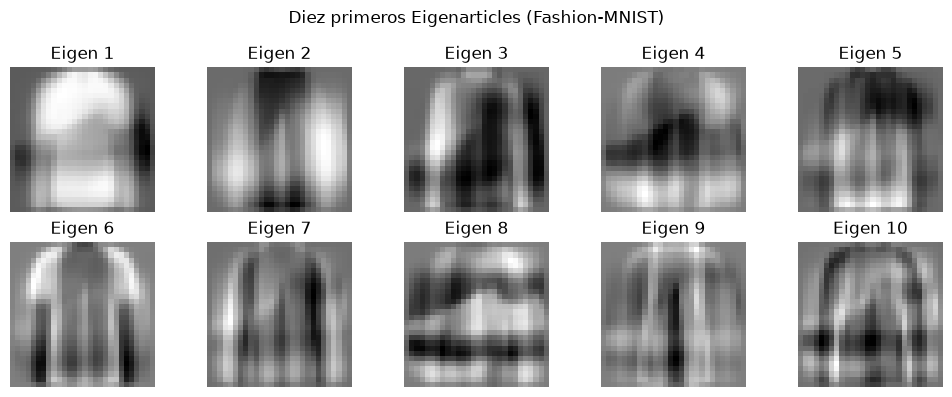

In [11]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Tomar la componente i y devolverla a forma de imagen 28x28
    eigenarticle = pca.components_[i].reshape(28, 28)
    plt.imshow(eigenarticle, cmap='gray')
    plt.title(f'Eigen {i+1}')
    plt.axis('off')
plt.suptitle('Diez primeros Eigenarticles (Fashion-MNIST)')
plt.tight_layout()
plt.show()

No son fotos individuales, sino las direcciones de mayor varianza calculadas sobre todo el dataset.
Las zonas claras y oscuras reflejan cómo cambian conjuntamente las características de las prendas.
 

### Comparación de las diez primeras imágenes de test con sus reconstrucciones usando $K = 600$

C:\Users\aleks\AppData\Local\Temp\ipykernel_12624\3318504477.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


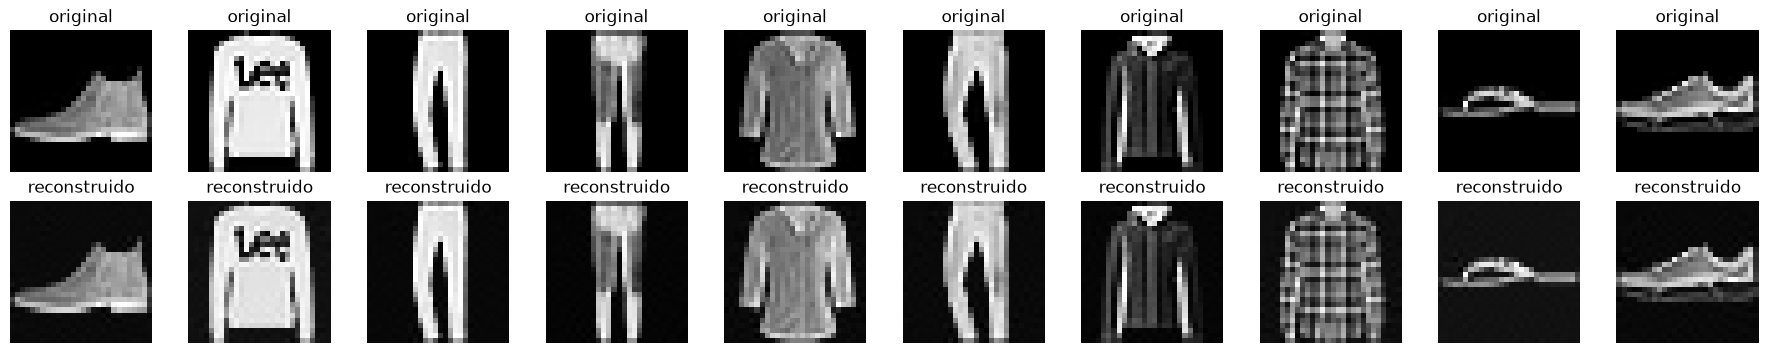

In [14]:
pca_600 = PCA(n_components=600, svd_solver='randomized', random_state=42)
pca_600.fit(X_train)

X_test_subset = X_test[:10]
X_test_rec = pca_600.inverse_transform(pca_600.transform(X_test_subset))

# Visualización
fig, axs = plt.subplots(
    nrows=2, 
    ncols=10, 
    figsize=(18, 18 * 2 / 10), 
    constrained_layout=True
)
for i in range(10):
    # Imagen Original 
        ax = axs.flat[i]
        ax.set_axis_off()  # Ocultar los ejes
        ax.set_title(f"original")
        ax.imshow(
            X_test_subset[i, :].reshape((28, 28)), 
            cmap=plt.cm.gray, 
            interpolation="none"
        )
    
    # Imagen Reconstruida 
        ax = axs.flat[10 + i]
        ax.set_axis_off()  # Ocultar los ejes
        ax.set_title(f"reconstruido")
        ax.imshow(
            X_test_rec[i, :].reshape((28, 28)), 
            cmap=plt.cm.gray, 
            interpolation="none"
        )


plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

K = 200

y_train = fashion_mnist['train']['label']
y_test = fashion_mnist['test']['label']

pca_lr = PCA(n_components=K, svd_solver='randomized', random_state=42)
X_train_pca = pca_lr.fit_transform(X_train)
X_test_pca = pca_lr.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)

print(f"Precisión en test con K = {K}: {accuracy * 100:.2f}%")


Precisión en test con K = 200: 84.36%
